# Linear & Logistic Regression

**Goal:** Master the two most fundamental models in ML:
- **Linear Regression** — predict a continuous number
- **Logistic Regression** — predict a probability / class

**Why it matters:** These aren't just "beginner models". They're:
- Fast baselines every serious project starts with
- Interpretable (you can read the coefficients)
- Often competitive when features are good
- The foundation for understanding neural networks

**Prerequisite:** [02-preprocessing/02-scaling-encoding.ipynb](../02-preprocessing/02-scaling-encoding.ipynb)

**Datasets:**
- Linear Regression → California Housing (predict house prices)
- Logistic Regression → Titanic (predict survival)

---

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)



## PART 1 — Linear Regression

### The Idea

Linear Regression fits a line (or hyperplane) that minimizes the **sum of squared errors** between predictions and true values.

For one feature:


**Assumptions:**
1. Linear relationship between X and y
2. Errors are independent
3. Errors have constant variance (homoscedasticity)
4. Errors are normally distributed

When these break, Linear Regression underperforms — but it's still a strong baseline.

In [17]:

housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame

print("Shape:", df_housing.shape)
print("\nColumns:")
print(df_housing.columns.tolist())
print("\nTarget: MedHouseVal (median house value in $100k)")
df_housing.head()

Shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Target: MedHouseVal (median house value in $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.65  
max       41.95

Text(0.5, 0, 'Pearson Correlation')

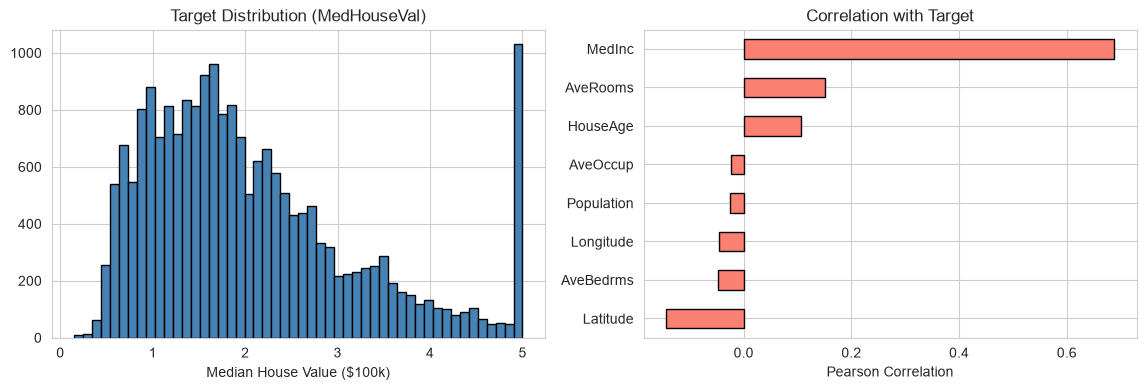

In [18]:
print(df_housing.describe().round(2))

fig , axes = plt.subplots(1,2,figsize=(14,4))

df_housing["MedHouseVal"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Target Distribution (MedHouseVal)")
axes[0].set_xlabel("Median House Value ($100k)")

corr_target = df_housing.corr()["MedHouseVal"].drop("MedHouseVal").sort_values()
corr_target.plot(kind="barh", ax=axes[1], color="salmon", edgecolor="black")
axes[1].set_title("Correlation with Target")
axes[1].set_xlabel("Pearson Correlation")


In [19]:
# Separate features and target
X = df_housing.drop(columns=["MedHouseVal"])
y = df_housing["MedHouseVal"]

# Train/test split — always before any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

Train: (16512, 8), Test: (4128, 8)
Target range: [0.15, 5.00]


In [20]:
# always predict the training mean
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (predict mean) RMSE: ${baseline_rmse * 100_000:,.0f}")
print(f"Baseline R²: {r2_score(y_test, baseline_pred):.4f}")

Baseline (predict mean) RMSE: $114,486
Baseline R²: -0.0002


In [21]:
# With scaling 
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

lr_pipe.fit(X_train, y_train)
y_pred_scaled = lr_pipe.predict(X_test)

print("=== Linear Regression (scaled) ===")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_scaled)) * 100_000:,.0f}")
print(f"MAE : ${mean_absolute_error(y_test, y_pred_scaled) * 100_000:,.0f}")
print(f"R²  : {r2_score(y_test, y_pred_scaled):.4f}")

=== Linear Regression (scaled) ===
RMSE: $74,558
MAE : $53,320
R²  : 0.5758


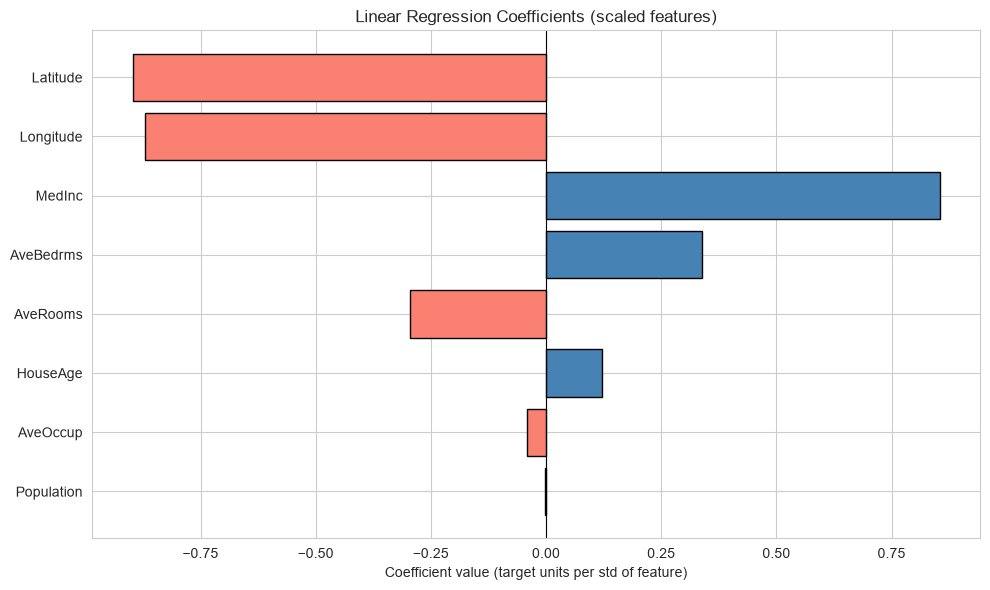

   feature  coefficient
  Latitude       -0.897
 Longitude       -0.870
    MedInc        0.854
 AveBedrms        0.339
  AveRooms       -0.294
  HouseAge        0.123
  AveOccup       -0.041
Population       -0.002


In [22]:
coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr_pipe.named_steps["model"].coef_,
}).sort_values("coefficient", key=abs, ascending=True)

plt.figure(figsize=(10, 6))
colors = ["salmon" if c < 0 else "steelblue" for c in coefs["coefficient"]]
plt.barh(coefs["feature"], coefs["coefficient"], color=colors, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients (scaled features)")
plt.xlabel("Coefficient value (target units per std of feature)")
plt.tight_layout()
plt.show()


print(coefs.sort_values("coefficient", key=abs, ascending=False).round(3).to_string(index=False))

Text(0.5, 1.0, 'Actual vs Predicted')

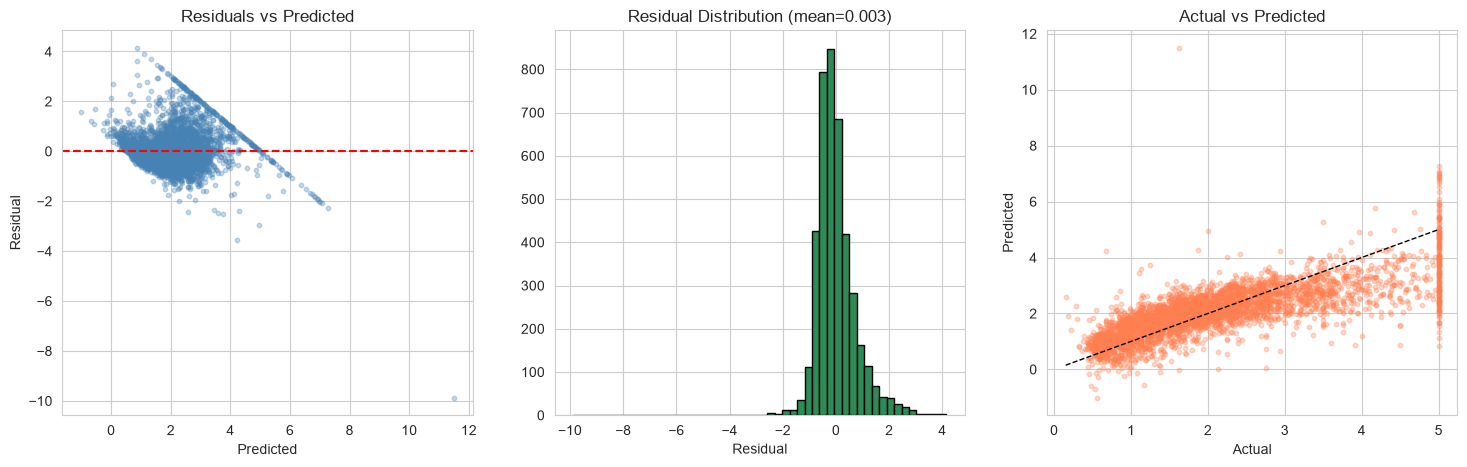

In [23]:
residuals = y_test - y_pred_scaled

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(y_pred_scaled, residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, color="seagreen", edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_title(f"Residual Distribution (mean={residuals.mean():.3f})")

axes[2].scatter(y_test, y_pred_scaled, alpha=0.3, s=10, color="coral")
axes[2].plot([y.min(), y.max()], [y.min(), y.max()], "k--", linewidth=1)
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")
axes[2].set_title("Actual vs Predicted")



## PART 2 — Regularization: Ridge & Lasso

### The Problem with Plain Linear Regression

When features are correlated or numerous, Linear Regression:
- **Overfits** (large coefficients that don't generalize)
- Becomes **unstable** (small data changes → huge coefficient changes)
- Can't handle **p > n** (more features than samples)

### The Fix — Add a Penalty

**Ridge (L2):** minimizes `MSE + α·Σwᵢ²`  
→ shrinks coefficients toward zero, but rarely exactly zero

**Lasso (L1):** minimizes `MSE + α·Σ|wᵢ|`  
→ can drive coefficients **exactly to zero** → automatic feature selection

**The α (alpha) parameter:**
- α = 0 → plain Linear Regression
- α small → mild regularization
- α large → heavy shrinkage (underfitting risk)

**Which to use?**
- Features all relevant → **Ridge**
- Suspect some features irrelevant → **Lasso**
- Best of both → **ElasticNet** (combines L1 + L2)

In [24]:
from sklearn.linear_model import Ridge , Lasso

models = {
  "Linear" : LinearRegression(),
  "Ridge α=1" : Ridge (alpha=1.0 , random_state=42),
  "Ridge α=10": Ridge(alpha=10.0, random_state=42),
  "Lasso α=0.01": Lasso(alpha=0.01, random_state=42, max_iter=10000),
  "Lasso α=0.1":  Lasso(alpha=0.1, random_state=42, max_iter=10000),

}

results = []
for name , model in models.items():
  pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²":   r2_score(y_test, y_pred),
        "Non-zero coefs": (pipe.named_steps["model"].coef_ != 0).sum(),
    })

results_df = pd.DataFrame(results)
results_df["RMSE"] = (results_df["RMSE"] * 100_000).round(0).astype(int)
results_df["R²"] = results_df["R²"].round(4)
print(results_df.to_string(index=False))



       Model  RMSE     R²  Non-zero coefs
      Linear 74558 0.5758               8
   Ridge α=1 74556 0.5758               8
  Ridge α=10 74534 0.5761               8
Lasso α=0.01 74044 0.5816               7
 Lasso α=0.1 82440 0.4814               3


## PART 3 — Logistic Regression

### The Idea

Despite the name, Logistic Regression is a **classifier**, not a regressor.

**Step 1:** Compute a linear combination (like Linear Regression):

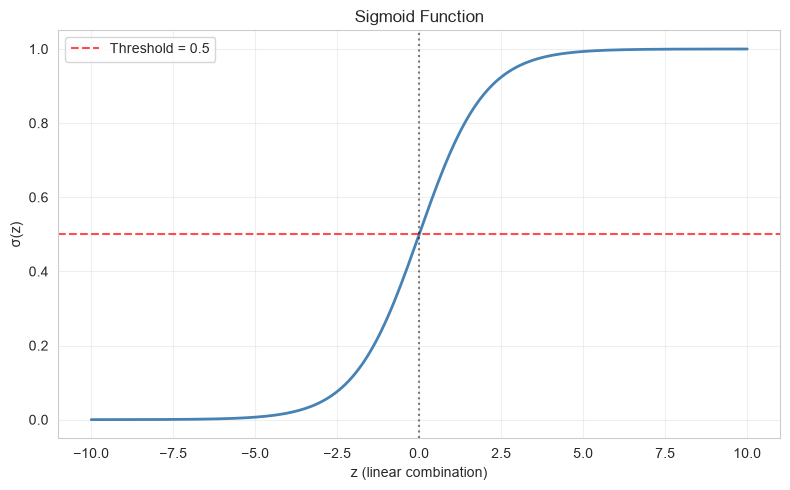

In [25]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, linewidth=2, color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="Threshold = 0.5")
plt.axvline(0, color="black", linestyle=":", alpha=0.5)
plt.xlabel("z (linear combination)")
plt.ylabel("σ(z)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Reload Titanic and apply the cleaning from previous notebooks
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["HasCabin"] = df["Cabin"].notna().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])



df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
         "Fare", "Embarked", "HasCabin", "FamilySize", "IsAlone"]]

print("Shape:", df.shape)
print("Survival rate:", df["Survived"].mean().round(3))
df.head(3)

Shape: (891, 11)
Survival rate: 0.384


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,0,2,0
1,1,1,female,38.0,1,0,71.2833,C,1,2,0
2,1,3,female,26.0,0,0,7.9250,S,0,1,1


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

X = df.drop(columns=["Survived"])
y = df["Survived"]

numeric_features = ["Age", "SibSp", "Parch", "Fare", "HasCabin", "FamilySize", "IsAlone"]
categorical_features = ["Pclass", "Sex", "Embarked"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train survival rate: {y_train.mean():.3f}")
print(f"Test  survival rate: {y_test.mean():.3f}")



Train: (712, 10), Test: (179, 10)
Train survival rate: 0.383
Test  survival rate: 0.385


In [29]:
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

logreg_pipe.fit(X_train, y_train)

y_pred = logreg_pipe.predict(X_test)
y_proba = logreg_pipe.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

Accuracy : 0.8101
Precision: 0.7869
Recall   : 0.6957
F1       : 0.7385
ROC-AUC  : 0.8418


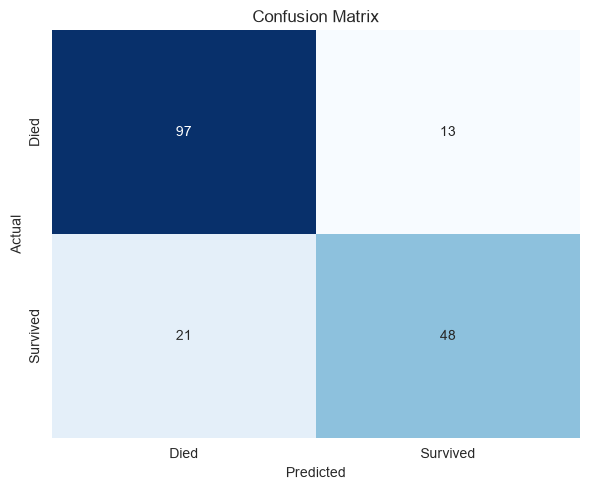

In [32]:
cm = confusion_matrix(y_test , y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm , annot=True , fmt="d" , cmap="Blues",
            xticklabels= ["Died", "Survived"],
            yticklabels=["Died", "Survived"],
            cbar=False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



In [33]:
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))

              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



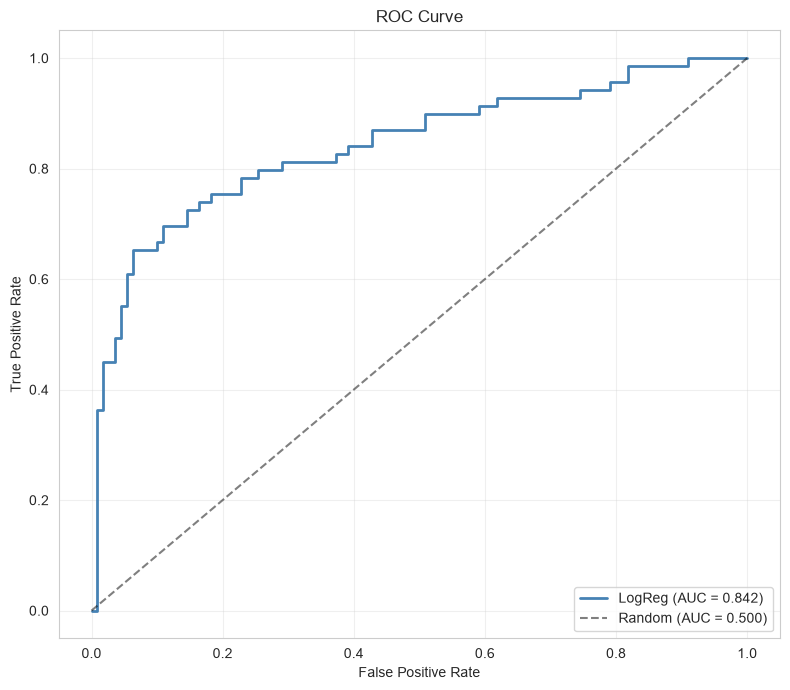

AUC = 0.8418


In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, linewidth=2, color="steelblue", label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC = {auc:.4f}")

## PART 4 — Beyond the Basics: Threshold Tuning & Class Weights

### Threshold Tuning

Default threshold is 0.5. But **when is 0.5 wrong?**

- **Spam filter**: prefer high precision → raise threshold
- **Cancer screening**: prefer high recall → lower threshold

You choose based on **cost of FP vs FN**.

### Class Weights

Imbalanced data → the majority class dominates.  
`class_weight="balanced"` re-weights samples inversely to class frequency.

In [35]:
# Predictions at different thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []
for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t),
    })

print(pd.DataFrame(results).round(4).to_string(index=False))

 Threshold  Accuracy  Precision  Recall     F1
       0.3    0.7598     0.6548  0.7971 0.7190
       0.4    0.7765     0.6933  0.7536 0.7222
       0.5    0.8101     0.7869  0.6957 0.7385
       0.6    0.8156     0.8750  0.6087 0.7179
       0.7    0.7989     0.8837  0.5507 0.6786


In [36]:
# Same pipeline, but balanced class weights
logreg_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])

logreg_balanced.fit(X_train, y_train)
y_pred_bal = logreg_balanced.predict(X_test)

print("=== Without class weights ===")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")

print("\n=== With class_weight='balanced' ===")
print(f"Precision: {precision_score(y_test, y_pred_bal):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_bal):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_bal):.4f}")

=== Without class weights ===
Precision: 0.7869
Recall   : 0.6957
F1       : 0.7385

=== With class_weight='balanced' ===
Precision: 0.6795
Recall   : 0.7681
F1       : 0.7211


In [37]:
cv_scores = cross_val_score(logreg_pipe, X, y, cv=5, scoring="roc_auc")

print(f"CV ROC-AUC scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
for m in metrics:
    scores = cross_val_score(logreg_pipe, X, y, cv=5, scoring=m)
    print(f"{m:10s}: {scores.mean():.4f} ± {scores.std():.4f}")


CV ROC-AUC scores: [0.8441 0.8293 0.859  0.8477 0.8848]
Mean: 0.8530 ± 0.0185
accuracy  : 0.8058 ± 0.0160
precision : 0.7708 ± 0.0385
recall    : 0.7075 ± 0.0382
f1        : 0.7364 ± 0.0229
roc_auc   : 0.8530 ± 0.0185


## Summary

### Linear Regression
- Predicts continuous values via **MSE minimization**
- **Interpretable** — coefficients tell you feature importance
- **Ridge/Lasso** add regularization: L2 shrinks, L1 selects features
- Always check **residuals** for pattern violations

### Logistic Regression
- Classifier disguised as regression — uses **sigmoid + log loss**
- Outputs **probabilities**, not just classes
- **Threshold tuning** matters (0.5 is not sacred)
- **class_weight** helps with imbalanced data

### When to Use Which
| Goal | Model |
|------|-------|
| Predict a number | Linear Regression |
| Predict a class | Logistic Regression |
| Interpret coefficients | Both (regularized versions) |
| Baseline for any project | Logistic Regression |
| Feature selection | Lasso |

## 🚀 Next

→ [02-tree-randomforest.ipynb](./02-tree-randomforest.ipynb): non-linear models that handle feature interactions automatically.

In [38]:
import joblib

joblib.dump(logreg_pipe, "logreg_titanic.joblib")
print("Saved: logreg_titanic.joblib")

Saved: logreg_titanic.joblib
